In [28]:
# 모듈 불러오기
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn as sk
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier


In [29]:
# 출력 짤림 방지
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# 한글 폰트 설정 (Windows 기본)
plt.rcParams["font.family"] = "Malgun Gothic"

# 마이너스 기호 깨짐 방지
plt.rcParams["axes.unicode_minus"] = False

In [30]:
# 데이터 불러오기
accepted_df = pd.read_csv('./data/accepted_2007_to_2018Q4.csv') # 승인된 대출 건

C:\Users\gmltk\AppData\Local\Temp\ipykernel_39664\3139296468.py:2: DtypeWarning: Columns (0: id, 1: desc, 2: next_pymnt_d, 3: verification_status_joint, 4: sec_app_earliest_cr_line, 5: hardship_type, 6: hardship_reason, 7: hardship_status, 8: hardship_start_date, 9: hardship_end_date, 10: payment_plan_start_date, 11: hardship_loan_status, 12: debt_settlement_flag_date, 13: settlement_status, 14: settlement_date) have mixed types. Specify dtype option on import or set low_memory=False.
  accepted_df = pd.read_csv('./data/accepted_2007_to_2018Q4.csv') # 승인된 대출 건


### EDA 시작

In [31]:
# 결측치 세기
accepted_df.isna().sum()


id                                                  0
member_id                                     2260701
loan_amnt                                          33
funded_amnt                                        33
funded_amnt_inv                                    33
term                                               33
int_rate                                           33
installment                                        33
grade                                              33
sub_grade                                          33
emp_title                                      167002
emp_length                                     146940
home_ownership                                     33
annual_inc                                         37
verification_status                                33
issue_d                                            33
loan_status                                        33
pymnt_plan                                         33
url                         

In [32]:
# 복사본 생성
eda1 = accepted_df.copy()

In [33]:
eda1[eda1['loan_amnt'].isna()].shape

(33, 151)

In [34]:
eda1 = eda1[eda1['loan_amnt'].notna()]
eda1[eda1['settlement_date'].notna()].head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,last_fico_range_high,last_fico_range_low,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_act_il,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,revol_bal_joint,sec_app_fico_range_low,sec_app_fico_range_high,sec_app_earliest_cr_line,sec_app_inq_last_6mths,sec_app_mort_acc,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,hardship_flag,hardship_type,hardship_reason,hardship_status,deferral_term,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
68,68506862,NaN,20000.0,20000.0,20000.0,60 months,13.99,465.27,C,C4,Facilities Coordinator,10+ years,OWN,70000.0,Source Verified,Dec-2015,Charged Off,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,debt_consolidation,Debt consolidation,210xx,MD,16.90,0.0,Jun-2001,680.0,684.0,0.0,33.0,NaN,20.0,0.0,31200.0,42.0,35.0,w,0.0,0.0,15473.02,15473.02,2965.17,2592.85,0.00,9915.00,1784.7000,Jan-2017,465.27,NaN,Aug-2018,624.0,620.0,0.0,69.0,1.0,Individual,NaN,NaN,NaN,0.0,0.0,34856.0,2.0,1.0,0.0,0.0,43.0,3656.0,37.0,2.0,3.0,4367.0,41.0,74200.0,0.0,1.0,0.0,3.0,1835.0,18527.0,44.0,0.0,0.0,46.0,174.0,5.0,5.0,0.0,6.0,NaN,13.0,NaN,1.0,6.0,11.0,9.0,19.0,2.0,19.0,32.0,11.0,20.0,0.0,0.0,0.0,2.0,94.3,44.4,0.0,0.0,84200.0,34856.0,33100.0,10000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,Y,Nov-2017,COMPLETE,Sep-2017,9915.0,55.00,1.0
99,66615254,NaN,7200.0,7200.0,7200.0,36 months,17.27,257.67,D,D3,Department Manager,9 years,OWN,20000.0,Verified,Dec-2015,Charged Off,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,debt_consolidation,Debt consolidation,023xx,MA,13.21,1.0,Apr-2003,705.0,709.0,1.0,23.0,NaN,8.0,0.0,7302.0,32.6,17.0,w,0.0,0.0,3767.42,3767.42,2002.17,1041.44,0.00,723.81,130.2858,Dec-2016,257.67,NaN,Jul-2018,549.0,545.0,0.0,NaN,1.0,Individual,NaN,NaN,NaN,0.0,0.0,7302.0,2.0,0.0,1.0,1.0,12.0,0.0,NaN,3.0,4.0,5509.0,33.0,22400.0,2.0,0.0,3.0,5.0,913.0,9831.0,41.8,0.0,0.0,128.0,152.0,5.0,5.0,0.0,5.0,23.0,0.0,23.0,0.0,3.0,4.0,5.0,10.0,2.0,8.0,15.0,4.0,8.0,0.0,0.0,0.0,4.0,94.1,0.0,0.0,0.0

In [35]:
eda1['diff_amnt'] = eda1['loan_amnt'] - eda1['funded_amnt']
eda1[eda1['diff_amnt']>=1].head()


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,last_fico_range_high,last_fico_range_low,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_act_il,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,revol_bal_joint,sec_app_fico_range_low,sec_app_fico_range_high,sec_app_earliest_cr_line,sec_app_inq_last_6mths,sec_app_mort_acc,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,hardship_flag,hardship_type,hardship_reason,hardship_status,deferral_term,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term,diff_amnt
684043,80749289,NaN,18000.0,10000.0,10000.0,36 months,12.99,336.90,C,C2,Manager,6 years,RENT,60000.0,Source Verified,Jun-2016,Current,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,small_business,Business,980xx,WA,20.45,0.0,Nov-2008,685.0,689.0,1.0,NaN,NaN,9.0,0.0,15537.0,43.4,12.0,w,273.39,273.39,11660.480000,11660.48,9726.61,1933.87,0.0,0.0,0.0,Mar-2019,336.90,Apr-2019,Mar-2019,694.0,690.0,0.0,NaN,1.0,Individual,NaN,NaN,NaN,0.0,155.0,28657.0,1.0,1.0,0.0,0.0,28.0,12376.0,62.0,1.0,1.0,4705.0,51.0,35800.0,0.0,1.0,2.0,1.0,3184.0,19046.0,39.7,0.0,0.0,74.0,90.0,4.0,4.0,0.0,43.0,NaN,4.0,NaN,0.0,4.0,5.0,5.0,6.0,2.0,7.0,9.0,5.0,9.0,0.0,0.0,0.0,1.0,100.0,0.0,0.0,0.0,56761.0,28657.0,31600.0,20045.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN,8000.0
684121,79101538,NaN,20000.0,10000.0,10000.0,36 months,7.39,310.56,A,A4,manager,10+ years,MORTGAGE,55000.0,Verified,Jun-2016,Current,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,debt_consolidation,Debt consolidation,114xx,NY,20.77,0.0,Jul-1996,705.0,709.0,0.0,58.0,NaN,10.0,0.0,16751.0,61.4,37.0,w,920.52,920.52,10244.370000,10244.37,9079.48,1164.89,0.0,0.0,0.0,Mar-2019,310.56,Apr-2019,Mar-2019,744.0,740.0,0.0,58.0,1.0,Joint App,110000.0,16.17,Not Verified,0.0,0.0,53218.0,0.0,1.0,1.0,1.0,12.0,1699.0,52.0,1.0,2.0,7589.0,60.0,27300.0,0.0,1.0,1.0,3.0,6652.0,4263.0,69.5,0.0,0.0,112.0,237.0,10.0,10.0,6.0,10.0,NaN,12.0,NaN,1.0,2.0,3.0,5.0,18.0,2.0,8.0,28.0,3.0,10.0,0.0,0.0,0.0,2.0,97.3,66.7,0.0,0.0,1

In [36]:
eda1['loan_status'].value_counts()

loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
Name: count, dtype: int64

In [37]:
eda1.isna().sum().sort_values()

id                                                  0
loan_amnt                                           0
funded_amnt                                         0
funded_amnt_inv                                     0
int_rate                                            0
term                                                0
installment                                         0
grade                                               0
issue_d                                             0
sub_grade                                           0
verification_status                                 0
home_ownership                                      0
purpose                                             0
url                                                 0
pymnt_plan                                          0
loan_status                                         0
addr_state                                          0
fico_range_low                                      0
fico_range_high             

In [38]:
eda1[eda1['zip_code'].isna()]

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,last_fico_range_high,last_fico_range_low,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_act_il,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,revol_bal_joint,sec_app_fico_range_low,sec_app_fico_range_high,sec_app_earliest_cr_line,sec_app_inq_last_6mths,sec_app_mort_acc,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,hardship_flag,hardship_type,hardship_reason,hardship_status,deferral_term,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term,diff_amnt
1736050,96387212,NaN,5600.0,5600.0,5600.0,36 months,15.99,196.86,C,C5,Electrician,10+ years,MORTGAGE,40000.0,Verified,Jan-2017,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,debt_consolidation,Debt consolidation,NaN,AL,22.86,0.0,Jul-2005,670.0,674.0,1.0,NaN,107.0,8.0,1.0,7129.0,68.5,18.0,f,0.0,0.0,6895.874445,6895.87,5600.0,1295.87,0.0,0.0,0.0,Feb-2019,176.2,NaN,Feb-2019,694.0,690.0,0.0,NaN,1.0,Individual,NaN,NaN,NaN,0.0,0.0,90183.0,1.0,3.0,0.0,6.0,15.0,10038.0,66.0,1.0,1.0,2363.0,67.0,10400.0,6.0,0.0,3.0,9.0,11273.0,3271.0,68.5,0.0,0.0,103.0,41.0,11.0,6.0,4.0,11.0,NaN,6.0,NaN,0.0,4.0,4.0,4.0,5.0,9.0,4.0,5.0,4.0,8.0,0.0,0.0,0.0,2.0,100.0,50.0,1.0,0.0,99094.0,17167.0,10400.0,15231.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN,0.0


In [39]:
eda1['desc'].unique()

<StringArray>
[                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         

In [40]:
features = ['loan_amnt','funded_amnt' ,'desc', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title', 'home_ownership', 'annual_inc', 'verification_status', 'purpose', 'dti', 'fico_range_low', 'fico_range_high', 'open_acc', 'revol_bal', 'revol_util', 'total_acc', 'loan_status']
df1 = eda1[features]

In [41]:
df1.isna().sum()

loan_amnt                    0
funded_amnt                  0
desc                   2134603
term                         0
int_rate                     0
installment                  0
grade                        0
sub_grade                    0
emp_title               166969
home_ownership               0
annual_inc                   4
verification_status          0
purpose                      0
dti                       1711
fico_range_low               0
fico_range_high              0
open_acc                    29
revol_bal                    0
revol_util                1802
total_acc                   29
loan_status                  0
dtype: int64

In [42]:
aa=df1[df1['annual_inc'].isna()].head()
aa

,loan_amnt,funded_amnt,desc,term,int_rate,installment,grade,sub_grade,emp_title,home_ownership,annual_inc,verification_status,purpose,dti,fico_range_low,fico_range_high,open_acc,revol_bal,revol_util,total_acc,loan_status
1654329,5000.0,5000.0,I will be relocating to Boston next month and ...,36 months,7.43,155.38,A,A2,NaN,NONE,NaN,Not Verified,other,1.0,800.0,804.0,NaN,0.0,NaN,NaN,Does not meet the credit policy. Status:Fully ...
1654330,7000.0,7000.0,"I am borrowing $7,000 for tuition and other ex...",36 months,7.75,218.55,A,A3,NaN,NONE,NaN,Not Verified,other,1.0,800.0,804.0,NaN,0.0,NaN,NaN,Does not meet the credit policy. Status:Fully ...
1654360,6700.0,6700.0,I am moving to Florida and would like to borro...,36 months,7.75,209.18,A,A3,NaN,NONE,NaN,Not Verified,other,1.0,800.0,804.0,NaN,0.0,NaN,NaN,Does not meet the credit policy. Status:Fully ...
1654413,6500.0,6500.0,"Hi, I'm buying a used car. Anybody on faceb...",36 months,8.38,204.84,A,A5,NaN,NONE,NaN,Not Verified,other,4.0,740.0,744.0,NaN,0.0,NaN,NaN,Does not meet the credit policy. Status:Fully ...


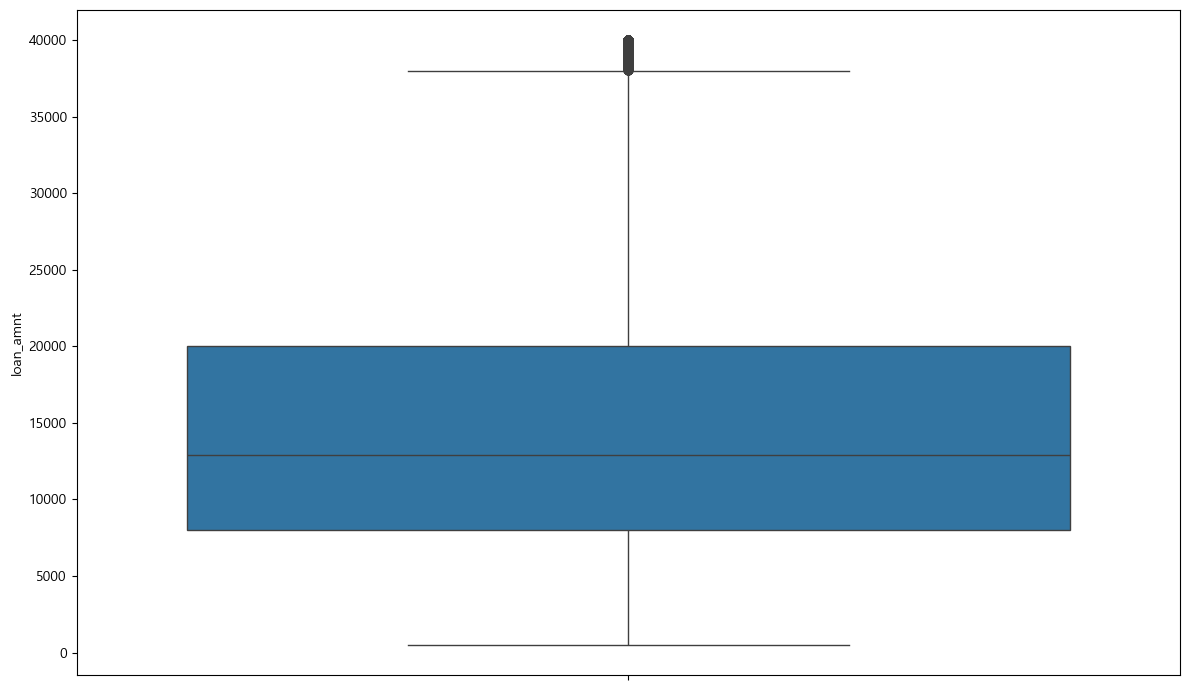

In [43]:
fig, ax = plt.subplots(figsize=(12,7))
sns.boxplot(df1['loan_amnt'])
plt.tight_layout()
plt.show()

In [44]:
aa = eda1[eda1['loan_amnt']>=40000]
aa.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,last_fico_range_high,last_fico_range_low,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_act_il,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,revol_bal_joint,sec_app_fico_range_low,sec_app_fico_range_high,sec_app_earliest_cr_line,sec_app_inq_last_6mths,sec_app_mort_acc,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,hardship_flag,hardship_type,hardship_reason,hardship_status,deferral_term,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term,diff_amnt
421139,130951046,NaN,40000.0,40000.0,40000.0,60 months,9.43,838.71,B,B1,Private Mortgage Banker,10+ years,MORTGAGE,150000.0,Not Verified,Mar-2018,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,debt_consolidation,Debt consolidation,107xx,NY,4.09,0.0,Aug-1996,730.0,734.0,0.0,NaN,117.0,6.0,1.0,4373.0,9.4,9.0,w,0.00,0.00,42645.053273,42645.05,40000.00,2645.05,0.0,0.0,0.0,Jan-2019,20264.30,NaN,Jan-2019,779.0,775.0,0.0,NaN,1.0,Individual,NaN,NaN,NaN,0.0,0.0,15615.0,0.0,1.0,0.0,0.0,47.0,11242.0,41.0,0.0,1.0,2647.0,21.0,46700.0,0.0,0.0,0.0,1.0,2603.0,39827.0,9.9,0.0,0.0,47.0,259.0,21.0,21.0,0.0,21.0,NaN,21.0,NaN,0.0,2.0,2.0,4.0,6.0,1.0,5.0,8.0,2.0,6.0,0.0,0.0,0.0,0.0,100.0,0.0,1.0,0.0,74455.0,15615.0,44200.0,27755.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN,0.0
421301,130838418,NaN,40000.0,40000.0,40000.0,36 months,6.71,1229.79,A,A3,physician,10+ years,MORTGAGE,250000.0,Source Verified,Mar-2018,Current,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,debt_consolidation,Debt consolidation,544xx,WI,7.63,0.0,May-1984,725.0,729.0,0.0,NaN,NaN,14.0,0.0,29843.0,50.4,27.0,w,28617.97,28617.97,13497.870000,13497.87,11382.03,2115.84,0.0,0.0,0.0,Feb-2019,1229.79,Apr-2019,Mar-2019,724.0,720.0,0.0,NaN,1.0,Individual,NaN,NaN,NaN,0.0,0.0,267993.0,0.0,1.0,0.0,0.0,44.0,5182.0,27.0,0.0,1.0,9697.0,45.0,59200.0,0.0,0.0,0.0,1.0,19142.0,22460.0,55.1,0.0,0.0,87.0,406.0,15.0,15.0,5.0,36.0,NaN,NaN,NaN,0.0,6.0,7.0,7.0,13.0,3.0,12.0,19.0,7.0,14.0,0.0,0.

In [45]:
eda1['application_type'].value_counts()

application_type
Individual    2139958
Joint App      120710
Name: count, dtype: int64

In [46]:
len(eda1['verification_status'].unique())

3

In [47]:
df1.isna().sum()


loan_amnt                    0
funded_amnt                  0
desc                   2134603
term                         0
int_rate                     0
installment                  0
grade                        0
sub_grade                    0
emp_title               166969
home_ownership               0
annual_inc                   4
verification_status          0
purpose                      0
dti                       1711
fico_range_low               0
fico_range_high              0
open_acc                    29
revol_bal                    0
revol_util                1802
total_acc                   29
loan_status                  0
dtype: int64

<Axes: ylabel='dti'>

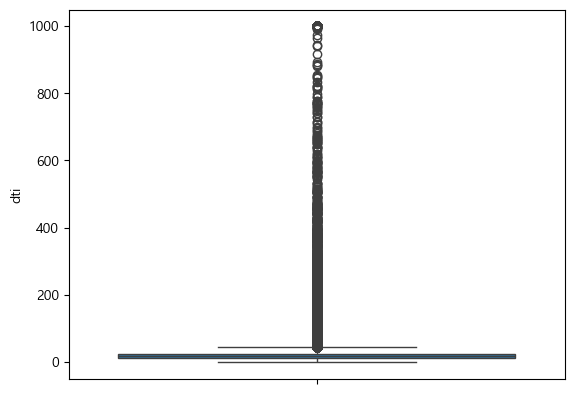

In [48]:
sns.boxplot(df1['dti'])

In [49]:
df1[df1['dti']>=990].head()

,loan_amnt,funded_amnt,desc,term,int_rate,installment,grade,sub_grade,emp_title,home_ownership,annual_inc,verification_status,purpose,dti,fico_range_low,fico_range_high,open_acc,revol_bal,revol_util,total_acc,loan_status
8721,6550.0,6550.0,NaN,36 months,17.86,236.34,D,D5,NaN,MORTGAGE,1770.0,Not Verified,credit_card,999.0,670.0,674.0,10.0,29029.0,84.4,25.0,Fully Paid
427740,10000.0,10000.0,NaN,36 months,6.07,304.54,A,A2,NaN,OWN,40.0,Verified,credit_card,999.0,835.0,839.0,4.0,1175.0,6.4,9.0,Current
429273,25000.0,25000.0,NaN,36 months,21.85,952.83,D,D5,NaN,RENT,850.0,Verified,debt_consolidation,999.0,685.0,689.0,12.0,29543.0,86.6,24.0,Current
448397,24000.0,24000.0,NaN,36 months,9.92,773.52,B,B2,Teacher,MORTGAGE,60.0,Not Verified,debt_consolidation,999.0,670.0,674.0,8.0,0.0,NaN,41.0,Current
452427,8000.0,8000.0,NaN,36 months,7.96,250.55,A,A5,Driver,MORTGAGE,800.0,Source Verified,debt_consolidation,999.0,685.0,689.0,8.0,5784.0,28.2,9.0,Fully Paid


In [55]:
# 전처리
df1['desc'] = df1['desc'].fillna('-')
df1['emp_title'] = df1['emp_title'].fillna('-')
df1['annual_inc'] = df1['annual_inc'].fillna(df1['annual_inc'].median())
df1['dti'] = df1['dti'].fillna(df1['dti'].median())
df1['revol_util'] = df1['revol_util'].fillna(df1['revol_util'].median())
df1['revol_bal'] = df1['revol_bal'].fillna(df1['revol_bal'].median())
df1['open_acc'] = df1['open_acc'].fillna(df1['open_acc'].median())
df1['total_acc'] = df1['total_acc'].fillna(df1['total_acc'].median())
df1.isna().sum()

loan_amnt              0
funded_amnt            0
desc                   0
term                   0
int_rate               0
installment            0
grade                  0
sub_grade              0
emp_title              0
home_ownership         0
annual_inc             0
verification_status    0
purpose                0
dti                    0
fico_range_low         0
fico_range_high        0
open_acc               0
revol_bal              0
revol_util             0
total_acc              0
loan_status            0
dtype: int64

In [52]:
# 종속변수 이진 분리 
# Good Loan(0) : Fully Paid, Current, In Grace Period, Does not meet the credit policy. Status: Fully Paid
# Bad Loan(1) : Charged Off, Default, Late (16-30 days), Late (31-120 days), Does not meet the credit policy. Status: Charged Off
print(df1['loan_status'].value_counts())
df1['loan_status'] = df1['loan_status'].replace(['Fully Paid', 'Current', 'In Grace Period', 'Does not meet the credit policy. Status:Fully Paid'], 0)
df1['loan_status'] = df1['loan_status'].replace(['Charged Off', 'Default', 'Late (16-30 days)', 'Late (31-120 days)', 'Does not meet the credit policy. Status:Charged Off'], 1)
print(df1['loan_status'].value_counts())


loan_status
0    1965492
1     295176
Name: count, dtype: int64
loan_status
0    1965492
1     295176
Name: count, dtype: int64


In [ ]:
train, test = train_test_split(df1, test_size=0.2, random_state=42)
X_train, y_train, X_test, y_test = 

,loan_amnt,funded_amnt,desc,term,int_rate,installment,grade,sub_grade,emp_title,home_ownership,annual_inc,verification_status,purpose,dti,fico_range_low,fico_range_high,open_acc,revol_bal,revol_util,total_acc,loan_status
0,3600.0,3600.0,NaN,36 months,13.99,123.03,C,C4,leadman,MORTGAGE,55000.0,Not Verified,debt_consolidation,5.91,675.0,679.0,7.0,2765.0,29.7,13.0,0
1,24700.0,24700.0,NaN,36 months,11.99,820.28,C,C1,Engineer,MORTGAGE,65000.0,Not Verified,small_business,16.06,715.0,719.0,22.0,21470.0,19.2,38.0,0
2,20000.0,20000.0,NaN,60 months,10.78,432.66,B,B4,truck driver,MORTGAGE,63000.0,Not Verified,home_improvement,10.78,695.0,699.0,6.0,7869.0,56.2,18.0,0
3,35000.0,35000.0,NaN,60 months,14.85,829.90,C,C5,Information Systems Officer,MORTGAGE,110000.0,Source Verified,debt_consolidation,17.06,785.0,789.0,13.0,7802.0,11.6,17.0,0
4,10400.0,10400.0,NaN,60 months,22.45,289.91,F,F1,Contract Specialist,MORTGAGE,104433.0,Source Verified,major_purchase,25.37,695.0,699.0,12.0,21929.0,64.5,35.0,0
